# **Intro to Graph Theory - Colab 03. 17.04.2026**

NetworkX is one of the most frequently used Python packages to create, manipulate, and mine graphs.

With NetworkX you can load and store networks in standard and nonstandard data formats, generate many types of random and classic networks, analyze network structure, build network models, design new network algorithms, draw networks, and much more.

Library documentation: <a>https://networkx.org/documentation/stable/</a> .


# Setup

In [1]:
# Import the NetworkX package and some other may-be-useful packages
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create a graph from dataset

The source of data can be any file like CSV (Comma Separated File), text file, etc.
A graph is often represented as an adjacency list or an adjacency matrix. Node and/or edge attributes (attributes) can be included in the graph data, as well as edge weights (capabilities).
This paragraph explains the basic methods how to read data in Python and convert the data into a graph.

In [2]:
# Create a graph manually
G = nx.Graph()
G.add_edges_from(
    [
        (0, 1),
        (0, 7),
        (1, 7),
        (1, 2),
        (2, 8),
        (2, 5),
        (2, 3),
        (3, 4),
        (3, 5),
        (4, 5),
        (5, 6),
        (6, 8),
        (7, 8),
    ]
)

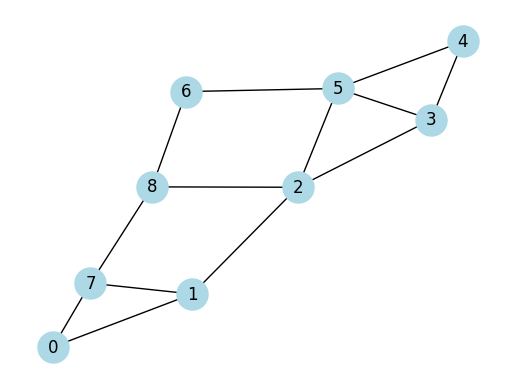

In [3]:
# Visualize the graph
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=500)
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")
plt.axis("off")
plt.show()

## Text file (.txt)

The file, usually, contains several lines. Each of the lines defines an edge in format $u\, \, v$, where $u$ and $v$ represents endpoints of the edge. Usually,   The vertices are  numbered from $1$ to $n$. or form $0$ to $n-1$.

In [4]:
# Read data as a DataFrame from a temporary repository
graph_data = pd.read_csv("graph.txt",  sep=" ", names=["from_node", "to_node"])
graph_data

,from_node,to_node
0,0,1
1,0,7
2,1,7
3,1,2
4,2,8
5,2,5
6,2,3
7,3,4
8,3,5
9,4,5


In [5]:
# Convert the DataFrame to the list of edges
graph_edges = np.array(graph_data)

graph_edges

array([[0, 1],
       [0, 7],
       [1, 7],
       [1, 2],
       [2, 8],
       [2, 5],
       [2, 3],
       [3, 4],
       [3, 5],
       [4, 5],
       [5, 6],
       [6, 8],
       [7, 8]])

In [6]:
# Greate a undirected graph and add edges from the list
H = nx.Graph()
H.add_edges_from(graph_edges)

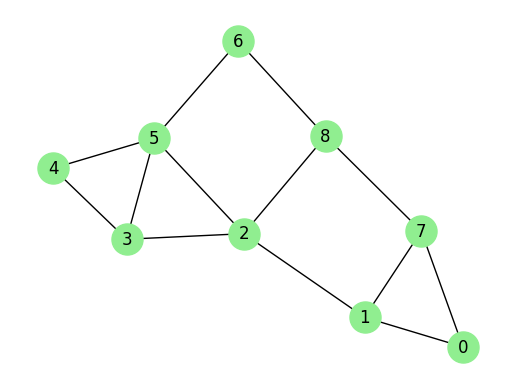

In [7]:
# Visualize the graph
pos = nx.spring_layout(H)
nx.draw_networkx_nodes(H, pos, node_color="lightgreen", node_size=500)
nx.draw_networkx_edges(H, pos)
nx.draw_networkx_labels(H, pos, font_size=12, font_family="sans-serif")
plt.axis("off")
plt.show()

In [8]:
# Greate a directed graph and add edges from the same list
F = nx.DiGraph()
F.add_edges_from(graph_edges)

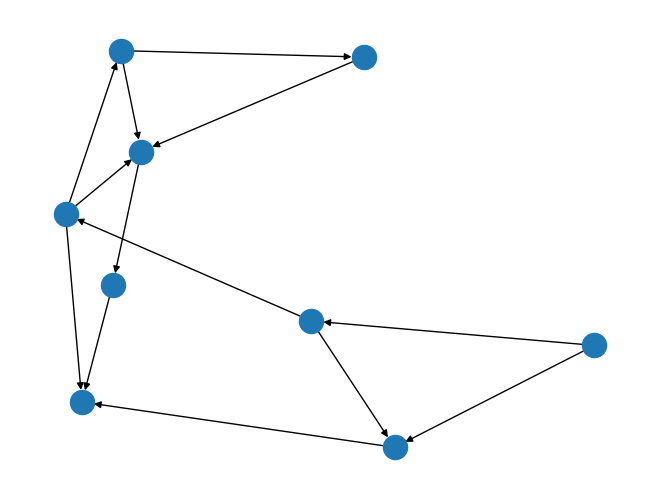

In [10]:
nx.draw(F)

In case of a weighted graph each edge is given as $u\,\, v\,\, w$ where $u$ and $v$ are vertices and $w$ is a weight.



In [11]:
# Read data as a DataFrame from a temporary repository
graph_data_weighted = pd.read_csv("graph_weighted.txt",  sep=" ", names=["from_node", "to_node", "weight"])
graph_data_weighted

,from_node,to_node,weight
0,0,1,4
1,0,7,8
2,1,7,11
3,1,2,8
4,2,8,2
5,2,5,4
6,2,3,7
7,3,4,9
8,3,5,14
9,4,5,10


In [12]:
graph_edges_weighted = np.array(graph_data_weighted)
graph_edges_weighted

array([[ 0,  1,  4],
       [ 0,  7,  8],
       [ 1,  7, 11],
       [ 1,  2,  8],
       [ 2,  8,  2],
       [ 2,  5,  4],
       [ 2,  3,  7],
       [ 3,  4,  9],
       [ 3,  5, 14],
       [ 4,  5, 10],
       [ 5,  6,  2],
       [ 6,  8,  6],
       [ 7,  8,  7]])

In [13]:
# Greate an undirected weighted graph
GG = nx.Graph()
GG.add_weighted_edges_from(graph_edges_weighted)

In [14]:
GG[0][1]

{'weight': np.int64(4)}

In [15]:
for u, v in GG.edges():
  wt = GG[u][v]['weight']
  print(f'Edge ({u},{v}) has a weight of {wt}')

Edge (0,1) has a weight of 4
Edge (0,7) has a weight of 8
Edge (1,7) has a weight of 11
Edge (1,2) has a weight of 8
Edge (7,8) has a weight of 7
Edge (2,8) has a weight of 2
Edge (2,5) has a weight of 4
Edge (2,3) has a weight of 7
Edge (8,6) has a weight of 6
Edge (5,3) has a weight of 14
Edge (5,4) has a weight of 10
Edge (5,6) has a weight of 2
Edge (3,4) has a weight of 9


In [16]:
# List of the graph weights
GG_weights = [GG[u][v]['weight'] for u, v in GG.edges()]

GG_weights

[np.int64(4),
 np.int64(8),
 np.int64(11),
 np.int64(8),
 np.int64(7),
 np.int64(2),
 np.int64(4),
 np.int64(7),
 np.int64(6),
 np.int64(14),
 np.int64(10),
 np.int64(2),
 np.int64(9)]

In [17]:
# Find minimum spanning tree
T = nx.minimum_spanning_tree(GG, algorithm="kruskal")

sorted(T.edges(data=True))

[(np.int64(0), np.int64(1), {'weight': np.int64(4)}),
 (np.int64(0), np.int64(7), {'weight': np.int64(8)}),
 (np.int64(2), np.int64(3), {'weight': np.int64(7)}),
 (np.int64(2), np.int64(5), {'weight': np.int64(4)}),
 (np.int64(2), np.int64(8), {'weight': np.int64(2)}),
 (np.int64(3), np.int64(4), {'weight': np.int64(9)}),
 (np.int64(5), np.int64(6), {'weight': np.int64(2)}),
 (np.int64(7), np.int64(8), {'weight': np.int64(7)})]

In [18]:
# Total weight of the MST
print(sum([T[u][v]['weight'] for u, v in T.edges()]))

43


## CSV file

In [19]:
# Read a csv file (dataset based in characters of "Game of thrones" HBO series)
got = pd.read_csv('got-s1-edges.csv', sep=',')

got

,Source,Target,Weight,Season
0,NED,ROBERT,192,1
1,DAENERYS,JORAH,154,1
2,JON,SAM,121,1
3,LITTLEFINGER,NED,107,1
4,NED,VARYS,96,1
...,...,...,...,...
544,SANSA,STANNIS,2,1
545,STANNIS,TOMARD,2,1
546,THEON,WILL,2,1
547,TYRION,TYSHA,2,1


In [20]:
# Drop columns we don not need
got.drop(columns={'Weight', 'Season'}, inplace=True)

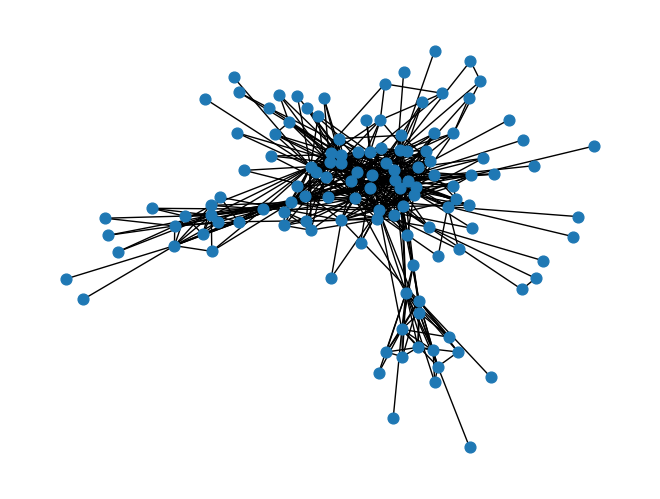

In [22]:
# Convert the data  to the list of edges, then create a graph
got_edges = np.array(got)
got_gr = nx.Graph()
got_gr.add_edges_from(got_edges)

# visualize a graph
nx.draw(got_gr, node_size=60)

In [23]:
got_N = got_gr.number_of_nodes()
got_L = got_gr.number_of_edges()

print(f'Number of nodes: {got_N}', f'Number of edges: {got_L}', sep='\n')

Number of nodes: 126
Number of edges: 549


In [24]:
got_diam = nx.diameter(got_gr)

print(f'Diameter of the graph: {got_diam}')

Diameter of the graph: 6


In [25]:
# List of degrees of the graph verticies

got_degree_lst = [got_gr.degree(v) for v in got_gr.nodes]

got_degree_lst

[57,
 36,
 18,
 15,
 26,
 12,
 26,
 21,
 13,
 28,
 36,
 30,
 12,
 41,
 29,
 3,
 27,
 26,
 16,
 9,
 6,
 17,
 16,
 19,
 20,
 10,
 24,
 8,
 17,
 5,
 3,
 8,
 16,
 9,
 8,
 8,
 8,
 9,
 7,
 12,
 7,
 7,
 8,
 7,
 6,
 13,
 5,
 9,
 11,
 6,
 4,
 16,
 8,
 4,
 18,
 5,
 3,
 7,
 7,
 6,
 4,
 5,
 6,
 3,
 2,
 9,
 11,
 5,
 9,
 2,
 4,
 2,
 7,
 3,
 3,
 13,
 9,
 10,
 1,
 6,
 6,
 4,
 7,
 3,
 2,
 2,
 2,
 2,
 4,
 10,
 8,
 3,
 1,
 2,
 1,
 3,
 3,
 2,
 3,
 2,
 2,
 5,
 2,
 1,
 3,
 1,
 2,
 2,
 2,
 2,
 1,
 3,
 3,
 1,
 2,
 3,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

# Exercise

1. Create an undirected graph from a file soc-dolphins.csv . Check which character is used as the delimiter in the file!
    - Find the number of vertices and edges in the graph
    - Determine whether the graph is connected.
    - What is the maximum degree of a vertex in the graph?
    - How many vertices have degree 1?
    - Compute the diameter of the graph.


In [27]:
data = pd.read_csv("soc-dolphins.csv",  sep=";")
data

,source,target
0,10,0
1,14,0
2,15,0
3,40,0
4,42,0
...,...,...
154,57,48
155,51,50
156,55,51
157,61,53


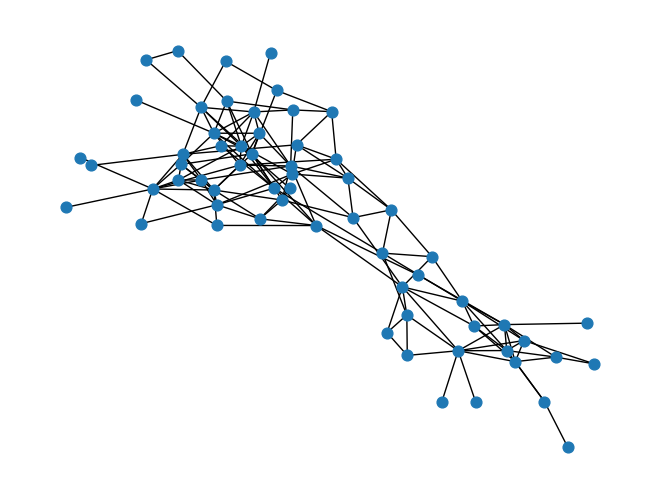

In [28]:
data_edges = np.array(data)
data_gr = nx.Graph()
data_gr.add_edges_from(data_edges)

# visualize a graph
nx.draw(data_gr, node_size=60)

In [30]:
n = data_gr.number_of_nodes()
m = data_gr.number_of_edges()
print(f"Nodes: {n}")
print(f"Edges: {m}")

Nodes: 62
Edges: 159


In [31]:
is_connected = nx.is_connected(data_gr)
print(f"connection: {is_connected}")

connection: True


In [32]:
max_degree = max(dict(data_gr.degree()).values())
print(f"maxdegree: {max_degree}")

maxdegree: 12


In [33]:
degree_1_count = sum(1 for d in dict(data_gr.degree()).values() if d == 1)
print(f"degree1: {degree_1_count}")

degree1: 9


In [34]:
diameter = nx.diameter(data_gr)
print(f"diameter: {diameter}")

diameter: 8
